In [2]:
!pip install

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 2.9 MB/s eta 0:00:00


In [3]:
from deap import base, creator, tools

import random
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# problem constants:
ONE_MAX_LENGTH = 100  # length of bit string to be optimized

# Genetic Algorithm constants:
POPULATION_SIZE = 200
P_CROSSOVER = 0.9  # probability for crossover
P_MUTATION = 0.1   # probability for mutating an individual
MAX_GENERATIONS = 50


# set the random seed:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

In [5]:
toolbox = base.Toolbox()

# create an operator that randomly returns 0 or 1:
toolbox.register("zeroOrOne", random.randint, 0, 1)

# define a single objective, maximizing fitness strategy:
creator.create("FitnessMax", base.Fitness, weights=(1.0,))

# create the Individual class based on list:
creator.create("Individual", list, fitness=creator.FitnessMax)

# create the individual operator to fill up an Individual instance:
toolbox.register("individualCreator", tools.initRepeat, creator.Individual, toolbox.zeroOrOne, ONE_MAX_LENGTH)

# create the population operator to generate a list of individuals:
toolbox.register("populationCreator", tools.initRepeat, list, toolbox.individualCreator)

In [6]:
# fitness calculation:
# compute the number of '1's in the individual
def oneMaxFitness(individual):
    return sum(individual),  # return a tuple


toolbox.register("evaluate", oneMaxFitness)

In [7]:
# genetic operators:

# Tournament selection with tournament size of 3:
toolbox.register("select", tools.selTournament, tournsize=3)

# Single-point crossover:
toolbox.register("mate", tools.cxOnePoint)

# Flip-bit mutation:
# indpb: Independent probability for each attribute to be flipped
toolbox.register("mutate", tools.mutFlipBit, indpb=1.0/ONE_MAX_LENGTH)

In [12]:
# create initial population (generation 0):
population = toolbox.populationCreator(n=POPULATION_SIZE)
generationCounter = 0

# calculate fitness tuple for each individual in the population:
fitnessValues = list(map(toolbox.evaluate, population))
for individual, fitnessValue in zip(population, fitnessValues):
    individual.fitness.values = fitnessValue

# extract fitness values from all individuals in population:
fitnessValues = [individual.fitness.values[0] for individual in population]

# initialize statistics accumulators:
maxFitnessValues = []
meanFitnessValues = []

# main evolutionary loop:
# stop if max fitness value reached the known max value
# OR if number of generations exceeded the preset value:
while max(fitnessValues) < ONE_MAX_LENGTH and generationCounter < MAX_GENERATIONS:
    # update counter:
    generationCounter = generationCounter + 1

    # apply the selection operator, to select the next generation's individuals:
    offspring = toolbox.select(population, len(population))
    # clone the selected individuals:
    offspring = list(map(toolbox.clone, offspring))

    # apply the crossover operator to pairs of offspring:
    for child1, child2 in zip(offspring[::2], offspring[1::2]):
        if random.random() < P_CROSSOVER:
            toolbox.mate(child1, child2)
            del child1.fitness.values
            del child2.fitness.values

    for mutant in offspring:
        if random.random() < P_MUTATION:
            toolbox.mutate(mutant)
            del mutant.fitness.values

    # calculate fitness for the individuals with no previous calculated fitness value:
    freshIndividuals = [ind for ind in offspring if not ind.fitness.valid]
    freshFitnessValues = list(map(toolbox.evaluate, freshIndividuals))
    for individual, fitnessValue in zip(freshIndividuals, freshFitnessValues):
        individual.fitness.values = fitnessValue

    # replace the current population with the offspring:
    population = offspring

    # collect fitnessValues into a list, update statistics and print:
    fitnessValues = [ind.fitness.values[0] for ind in population]

    maxFitness = max(fitnessValues)
    meanFitness = sum(fitnessValues) / len(population)
    maxFitnessValues.append(maxFitness)
    meanFitnessValues.append(meanFitness)
    print(f"- Generation {generationCounter}: Max Fitness = {maxFitness}, Avg Fitness = {meanFitness}")

    # find and print best individual:
    best_index = fitnessValues.index(max(fitnessValues))
    print("Best Individual = ", *population[best_index], "\n")


- Generation 1: Max Fitness = 66.0, Avg Fitness = 54.375
Best Individual =  1 0 1 1 0 1 1 1 1 1 0 0 0 1 0 1 1 0 0 0 1 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 0 1 1 1 1 1 0 1 1 1 1 0 0 0 0 1 1 0 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 0 0 

- Generation 2: Max Fitness = 68.0, Avg Fitness = 57.99
Best Individual =  0 1 0 1 1 1 1 1 1 0 1 1 0 1 1 1 0 1 0 0 1 1 1 1 0 0 1 1 1 1 1 1 0 0 1 1 0 1 1 0 0 1 1 1 1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 0 0 1 0 1 1 1 1 1 0 1 1 1 1 0 0 0 0 1 1 0 0 1 1 1 1 1 0 1 1 1 0 1 1 1 0 1 0 0 

- Generation 3: Max Fitness = 69.0, Avg Fitness = 61.285
Best Individual =  1 1 1 0 0 1 1 1 1 1 1 1 1 1 0 1 1 1 0 0 0 0 0 1 0 0 1 0 1 1 1 1 0 1 1 1 1 1 0 0 1 0 0 1 1 0 1 0 1 1 0 1 1 1 1 0 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 0 1 1 1 1 1 1 1 0 1 0 1 0 1 1 0 0 0 1 1 0 1 1 1 1 1 0 

- Generation 4: Max Fitness = 73.0, Avg Fitness = 64.165
Best Individual =  1 1 1 1 1 1 1 1 1 1 0 1 0 0 1 0 1 1 1 0 1 1 0 1 1 1 1 1 0 0 1 0 1 1 1 0 1 0 1 0 0 0 1 1 1 0

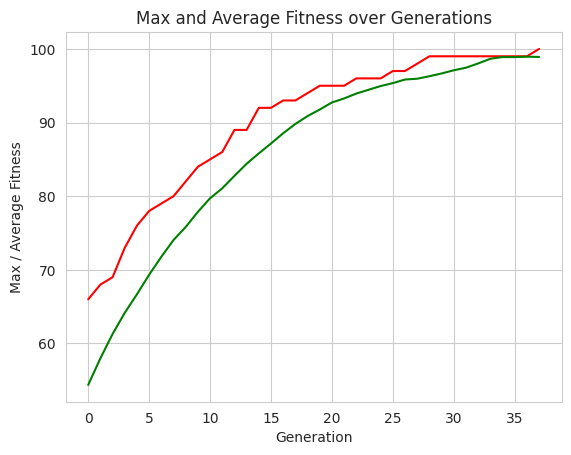

In [13]:
# Genetic Algorithm is done - plot statistics:
sns.set_style("whitegrid")
plt.plot(maxFitnessValues, color='red')
plt.plot(meanFitnessValues, color='green')
plt.xlabel('Generation')
plt.ylabel('Max / Average Fitness')
plt.title('Max and Average Fitness over Generations')

plt.show()